# 01 — The DECAL detector and its data

This first notebook looks at **what we simulate
and what comes out**: open one simulation file, understand the detector geometry
that *quantizes* every shower into 100 µm pixels, watch a single photon shower
land on that geometry, and make a few first-look plots.

DECAL = **D**igital **E**lectromagnetic **CAL**orimeter: instead of measuring
analog charge, the silicon is finely pixelated (100 µm) and each pixel is
essentially a *yes/no* hit. Counting hits ≈ counting particles — until the shower
gets so dense that pixels saturate. Exploring that trade-off is the whole
project, and it all starts from the geometry and data shown here.

By the end of this notebook we will have **measured, from the geometry file and
the simulation data themselves**, the handful of numbers that characterize any
sampling calorimeter — the radiation-length and interaction-length budgets (§3b),
the depth of shower max and its logarithmic growth with energy (§6b), the
transverse containment radius (§6b), the sampling fraction (§8), and the MIP
scale that sets the readout threshold (§9) — and checked each against its
textbook expectation. Nothing here is taken on faith; the point is that the
simulation can defend every number the later notebooks rely on.

**Prerequisites**: `setup_calomaps.sh` sourced, and some simulation data present
(see [`docs/handbook.md`](../docs/handbook.md) §8 to generate a smoke-test sim).

**Kernel**: `Key4hep (CPU)` — no GPU needed.


## 1. Find a data file

In [1]:
import os
import uproot
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt

# CALOMAPS_DATA_BASE points to where simulation output lives (set by setup_calomaps.sh).
data_base = os.environ.get("CALOMAPS_DATA_BASE", os.path.expanduser("~/CALOMAPS-data"))
dataset_name = "data_spectrum_100um_400GeV"   # the main production dataset
dataset_dir = os.path.join(data_base, dataset_name)

# Pick the first file
import glob
files = sorted(glob.glob(os.path.join(dataset_dir, "sim_photons_part*.root")))
print(f"found {len(files)} files in {dataset_dir}")
print(f"opening first one: {files[0] if files else '(none — generate data first)'}")
filepath = files[0]


found 889 files in /home/murtazas/CALOMAPS-data/data_spectrum_100um_400GeV
opening first one: /home/murtazas/CALOMAPS-data/data_spectrum_100um_400GeV/sim_photons_part1.root


## 2. What's inside the file?

The file is a ROOT file. Inside is a `TTree` named `events` (one entry per simulated event), with a flat list of branches that pack everything: truth-particle info, hit positions, hit energies, layer IDs, cell IDs, etc.

`uproot` lets us read these without depending on the C++ ROOT install.


In [2]:
with uproot.open(filepath) as f:
    print("top-level keys in the file:")
    for k in f.keys()[:8]:
        print(f"  {k}")
    print("...")
    tree = f["events"]
    print(f"\nevents.num_entries = {tree.num_entries}")
    print(f"number of branches  = {len(tree.keys())}")
    print(f"\nfirst 10 branches:")
    for k in tree.keys()[:10]:
        print(f"  {k}")


top-level keys in the file:
  events;1
  runs;1
  meta;1
  metadata;1
  podio_metadata;1
...

events.num_entries = 20
number of branches  = 68

first 10 branches:
  ECalBarrelHits
  ECalBarrelHits/ECalBarrelHits.cellID
  ECalBarrelHits/ECalBarrelHits.energy
  ECalBarrelHits/ECalBarrelHits.position.x
  ECalBarrelHits/ECalBarrelHits.position.y
  ECalBarrelHits/ECalBarrelHits.position.z
  ECalBarrelHits/ECalBarrelHits.contributions_begin
  ECalBarrelHits/ECalBarrelHits.contributions_end
  _ECalBarrelHits_contributions
  _ECalBarrelHits_contributions/_ECalBarrelHits_contributions.index


## 3. The detector geometry — a *quantized* calorimeter

The ECal is a **12-sided silicon barrel** (a dodecagonal tube) whose axis runs
along **z**. Radially it is a sandwich of **30 silicon sensor layers** interleaved
with tungsten absorber, between r = 1264 mm (inner face) and r = 1403 mm. Two
kinds of quantization define a DECAL:

- **Transverse**: each layer is tiled into **100 µm pixels** — the spatial quantum.
  A hit is a *pixel*, not a continuous position.
- **Longitudinal**: the shower is sampled at **30 discrete depths** (the layers).

We parse the layer radii straight out of the geometry XML below, and reuse them
to overlay the detector on the data.

In [3]:
import os, glob, xml.etree.ElementTree as ET
import uproot, awkward as ak, numpy as np, matplotlib.pyplot as plt

# Resolve the repo root. Prefer $CALOMAPS_HOME (exported by `source setup_calomaps.sh`
# in a terminal); otherwise auto-locate it by walking up from the kernel's working
# directory, so the notebook also works when opened from the JupyterLab GUI — whose
# kernel does NOT inherit a terminal's environment.
def _calomaps_home():
    h = os.environ.get("CALOMAPS_HOME")
    if h and os.path.isdir(os.path.join(h, "geometry")):
        return h
    p = os.path.abspath(os.getcwd())
    while p != os.path.dirname(p):
        if os.path.isdir(os.path.join(p, "geometry")) and os.path.isdir(os.path.join(p, "sim")):
            return p
        p = os.path.dirname(p)
    return os.path.expanduser("~/CALOMAPS")
CALOMAPS_HOME = _calomaps_home()
DATA_BASE = os.environ.get("CALOMAPS_DATA_BASE", os.path.expanduser("~/CALOMAPS-data"))

def parse_sid_value(v, constants):
    if not v: return 0.0
    if v in constants: return parse_sid_value(constants[v], constants)
    s = v.replace('*', ' * ').replace('cm', '10').replace('mm', '1')
    try: return eval(s, {"__builtins__": None}, {})
    except: return float(v)

geom_dir = os.path.join(CALOMAPS_HOME, "geometry")
main_xml = ET.parse(os.path.join(geom_dir, "SiD_TestBeam.xml")).getroot()
consts = {c.get("name"): c.get("value") for c in main_xml.findall(".//constant")}
custom_xml = ET.parse(os.path.join(geom_dir, "my_custom_ecal.xml")).getroot()
det = custom_xml.find(".//detector[@name='ECalBarrel']")

rmin = parse_sid_value(det.find("dimensions").get("rmin"), consts)
print(f"Detector face (rmin): {rmin:.2f} mm")

sensor_y_planes = []
curr_y = rmin
for layer in det.findall("layer"):
    rep = int(layer.get("repeat", 1))
    slices = layer.findall("slice")
    thick = sum(parse_sid_value(s.get("thickness"), consts) for s in slices)
    si_off = 0
    off = 0
    for s in slices:
        t = parse_sid_value(s.get("thickness"), consts)
        if s.get("material") == "Silicon":
            si_off = off + t / 2.0
        off += t
    for _ in range(rep):
        sensor_y_planes.append(curr_y + si_off)
        curr_y += thick

print(f"Total silicon layers: {len(sensor_y_planes)}")
print(f"First 5 layers at y = {[f'{y:.2f}' for y in sensor_y_planes[:5]]} mm")
print(f"Last 5 layers at y  = {[f'{y:.2f}' for y in sensor_y_planes[-5:]]} mm")


Detector face (rmin): 1264.00 mm
Total silicon layers: 30
First 5 layers at y = ['1266.91', '1270.66', '1274.41', '1278.16', '1281.91'] mm
Last 5 layers at y  = ['1375.66', '1381.91', '1388.16', '1394.41', '1400.66'] mm


## 3b. Why tungsten, and how much? — the radiation-length budget

A photon doesn't deposit energy directly — it **showers**: pair production
(γ → e⁺e⁻) and bremsstrahlung (e± → e±γ) alternate, roughly doubling the particle
count while halving the energy per particle, until everything is soft enough to be
absorbed. Both processes are governed by one material property, the **radiation
length X₀** — the distance over which an electron loses all but 1/e of its energy
to bremsstrahlung (and 7/9 of a photon's pair-production mean free path). A
calorimeter must be **many X₀ deep** to contain the cascade, which is why the
absorber is **tungsten**: X₀ scales roughly as A/(Z(Z+1)ρ), so a dense, high-Z
metal packs the most shower development into the fewest millimetres.

Two details matter for the numbers, and both are computed below:

- The absorber in this geometry is not pure tungsten but the SiD material
  **TungstenDens24** (93% W, 6.1% Ni, 0.9% Fe by mass, ρ = 17.8 g/cm³). Its X₀
  follows from the PDG per-element values via the mass-fraction mixture rule
  1/X₀ = Σⱼ wⱼ/X₀ⱼ — about **3.9 mm**, noticeably longer than pure tungsten's
  3.50 mm. Quoting the pure-W value would overstate the detector's depth by ~12%.
- The same accounting with **nuclear interaction lengths λ_I** (the hadronic
  analogue of X₀) shows this stack is only **~1 λ_I** deep — ample for photons,
  far too shallow to contain hadrons. That single comparison is why this is an
  *electromagnetic* calorimeter, and why the pion sibling notebook
  ([01b](01b_detector_and_data_pions.ipynb)) looks so different.

The multiplication stops once e± drop below the **critical energy** E_c (≈ 8 MeV
for tungsten), where ionization overtakes bremsstrahlung — which fixes the depth
of shower max at t_max ≈ ln(E/E_c) + ½ radiation lengths (checked against the
data in §6b). The cell prints the full budget and draws the stack: the repeating
unit cell (W / air / Si / Cu / Kapton / air) and the cumulative depth in X₀ — the
axis on which shower physics actually happens.


TungstenDens24: X0 = 3.93 mm (pure W: 3.50 mm), lambda_I = 105 mm
per-layer depth: thin cells 0.64 X0, thick cells 1.28 X0
TOTAL STACK: 25.7 X0   |   1.00 lambda_I
expected shower max t_max ~ ln(E/E_c) + 0.5 (photon-induced), E_c = 7.97 MeV:
   E =   5 GeV -> t_max ~ 6.9 X0  (of 25.7 available)
   E =  50 GeV -> t_max ~ 9.2 X0  (of 25.7 available)
   E = 400 GeV -> t_max ~ 11.3 X0  (of 25.7 available)


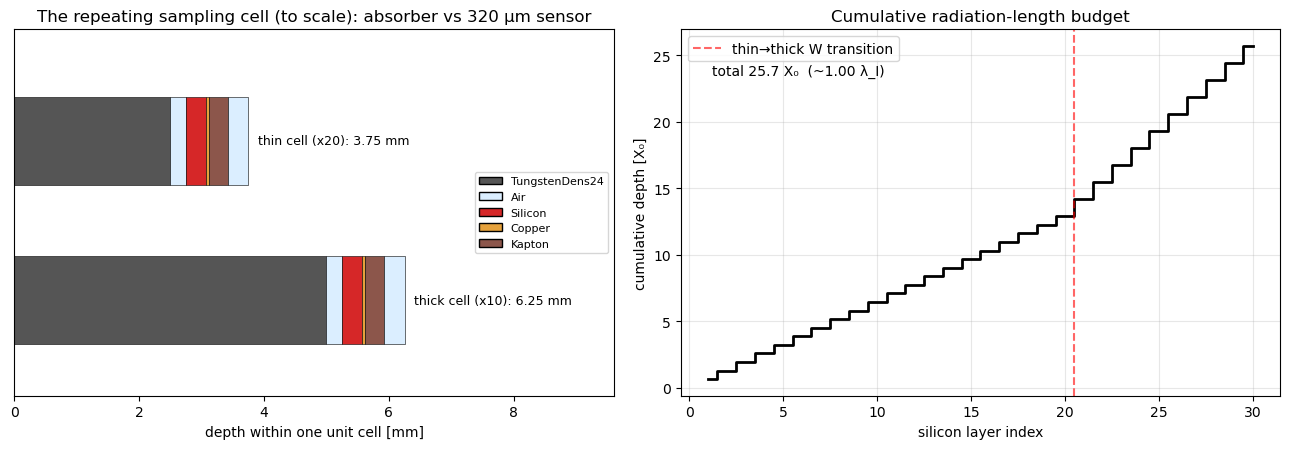

In [4]:
# --- radiation-length / interaction-length budget: geometry XML + PDG material data ---
# PDG per-element values: (X0 [g/cm^2], lambda_I [g/cm^2]); mixture rule 1/L = sum(w_j / L_j).
PDG_ELEM = {"W": (6.76, 191.9), "Ni": (12.68, 134.1), "Fe": (13.84, 132.1)}
# TungstenDens24 (SiD material database): 93% W + 6.1% Ni + 0.9% Fe by mass, rho = 17.8 g/cm^3
FRAC, RHO_ALLOY = {"W": 0.93, "Ni": 0.061, "Fe": 0.009}, 17.8
X0_alloy = 1.0 / sum(FRAC[e] / PDG_ELEM[e][0] for e in FRAC) / RHO_ALLOY * 10.0   # mm
lI_alloy = 1.0 / sum(FRAC[e] / PDG_ELEM[e][1] for e in FRAC) / RHO_ALLOY * 10.0   # mm
X0_W_pure = 6.76 / 19.30 * 10.0                                                   # mm
# per-material (X0 [mm], lambda_I [mm]) for the other slices (PDG); air is effectively transparent
MAT = {"TungstenDens24": (X0_alloy, lI_alloy), "Silicon": (93.7, 465.2),
       "Copper": (14.36, 151.6), "Kapton": (285.7, 500.0), "Air": (3.04e5, 7.5e5)}

# walk the layer stack exactly as the geometry defines it (det/consts parsed in section 3)
stack = []                                      # one entry per physical layer: [(material, mm), ...]
for layer in det.findall("layer"):
    sl = [(s.get("material"), parse_sid_value(s.get("thickness"), consts)) for s in layer.findall("slice")]
    stack += [sl] * int(layer.get("repeat", 1))
per_layer_X0 = np.array([sum(t / MAT[m][0] for m, t in sl) for sl in stack])
per_layer_lI = np.array([sum(t / MAT[m][1] for m, t in sl) for sl in stack])
cum_X0 = np.cumsum(per_layer_X0)
# depth (in X0) of each SILICON mid-plane -- used by the shower-profile fits in section 6b
t_si, _acc = [], 0.0
for sl in stack:
    for m, t in sl:
        if m == "Silicon":
            t_si.append(_acc + 0.5 * t / MAT[m][0])
        _acc += t / MAT[m][0]
t_si = np.array(t_si)

E_C_MEV = 7.97   # PDG electron critical energy for tungsten (the absorber is 93% W by mass)
print(f"TungstenDens24: X0 = {X0_alloy:.2f} mm (pure W: {X0_W_pure:.2f} mm), lambda_I = {lI_alloy:.0f} mm")
print(f"per-layer depth: thin cells {per_layer_X0[0]:.2f} X0, thick cells {per_layer_X0[-1]:.2f} X0")
print(f"TOTAL STACK: {cum_X0[-1]:.1f} X0   |   {per_layer_lI.sum():.2f} lambda_I")
print(f"expected shower max t_max ~ ln(E/E_c) + 0.5 (photon-induced), E_c = {E_C_MEV} MeV:")
for Ed in (5, 50, 400):
    print(f"   E = {Ed:3d} GeV -> t_max ~ {np.log(Ed * 1000 / E_C_MEV) + 0.5:.1f} X0  (of {cum_X0[-1]:.1f} available)")

from matplotlib.patches import Patch
COLS = {"TungstenDens24": "#555555", "Air": "#dbeeff", "Silicon": "#d62728",
        "Copper": "#e6a23c", "Kapton": "#8c564b"}
fig, ax = plt.subplots(1, 2, figsize=(13, 4.6))
for row, sl, lab in [(1, stack[0], "thin cell (x20)"), (0, stack[-1], "thick cell (x10)")]:
    x = 0.0
    for m, t in sl:
        ax[0].barh(row, t, left=x, height=0.55, color=COLS[m], edgecolor="k", lw=0.4)
        x += t
    ax[0].text(x + 0.15, row, f"{lab}: {x:.2f} mm", va="center", fontsize=9)
ax[0].legend(handles=[Patch(fc=COLS[m], ec="k", label=m) for m in COLS], fontsize=8, loc="center right")
ax[0].set_yticks([]); ax[0].set_xlim(0, 9.6); ax[0].set_ylim(-0.6, 1.7)
ax[0].set_xlabel("depth within one unit cell [mm]")
ax[0].set_title("The repeating sampling cell (to scale): absorber vs 320 µm sensor")
ax[1].step(np.arange(1, len(cum_X0) + 1), cum_X0, where="mid", color="k", lw=2)
ax[1].axvline(20.5, color="red", ls="--", alpha=0.6, label="thin→thick W transition")
ax[1].text(1.2, cum_X0[-1] - 2.2, f"total {cum_X0[-1]:.1f} X₀  (~{per_layer_lI.sum():.2f} λ_I)", fontsize=10)
ax[1].set_xlabel("silicon layer index"); ax[1].set_ylabel("cumulative depth [X₀]")
ax[1].set_title("Cumulative radiation-length budget"); ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 4. Look at a single event

Each event is one photon fired from the origin in **+y**, showering in the
silicon. The hit collection is *jagged* (a different number of hits per event);
`awkward` handles that. Pull the first event's hits and truth energy.

In [5]:
with uproot.open(filepath) as f:
    tree = f["events"]
    # Read the first event only
    x = tree["ECalBarrelHits/ECalBarrelHits.position.x"].array(entry_stop=1)[0]
    y = tree["ECalBarrelHits/ECalBarrelHits.position.y"].array(entry_stop=1)[0]
    z = tree["ECalBarrelHits/ECalBarrelHits.position.z"].array(entry_stop=1)[0]
    e = tree["ECalBarrelHits/ECalBarrelHits.energy"].array(entry_stop=1)[0]
    # Truth particle: photon's true energy
    p_mc = tree["MCParticles/MCParticles.momentum.y"].array(entry_stop=1)[0]
    print(f"Event 0:")
    print(f"  truth photon momentum.y (= |p| for a +Y beam): {float(p_mc[0]):.2f} GeV")
    print(f"  number of pixel hits: {len(x)}")
    print(f"  hit x range:  [{ak.min(x):.1f}, {ak.max(x):.1f}] mm")
    print(f"  hit y range:  [{ak.min(y):.1f}, {ak.max(y):.1f}] mm   (entry face spans +1264..+1403; a large NEGATIVE min is cross-cavity leakage on the -y side)")
    print(f"  hit z range:  [{ak.min(z):.1f}, {ak.max(z):.1f}] mm")
    print(f"  hit energy range: [{ak.min(e)*1e6:.2f}, {ak.max(e)*1e6:.0f}] keV")
    print(f"  total visible E: {float(ak.sum(e)):.4f} GeV   (visible/true = the sampling fraction; measured in section 8)")


Event 0:
  truth photon momentum.y (= |p| for a +Y beam): 368.70 GeV
  number of pixel hits: 45295
  hit x range:  [-1304.5, 1312.0] mm
  hit y range:  [-1357.0, 1400.8] mm   (entry face spans +1264..+1403; a large NEGATIVE min is cross-cavity leakage on the -y side)
  hit z range:  [-1370.4, 1683.4] mm
  hit energy range: [0.01, 8851] keV
  total visible E: 5.2242 GeV   (visible/true = the sampling fraction; measured in section 8)


## 5. Visualize the event on the detector

The natural way to *see the whole detector* is the **transverse plane (x–y)** —
perpendicular to the beam axis — where the full 12-sided ring is visible. The
photon travels **outward from the origin** and enters the **inner** face
(r = 1264 mm).

Two views:
1. **Transverse cross-section (x–y)** — the whole barrel ring. Most hits land on
   the +y entry face, but a single shower isn't fully contained: soft secondaries
   leak across the inner air cavity and strike the other faces too — which is why
   hits appear all the way around the ring.
2. **Zoom on the +y entry face** — the same plane, with the 30 silicon layers
   drawn. Increasing radius is increasing depth, so this is where the shower develops
   layer by layer.

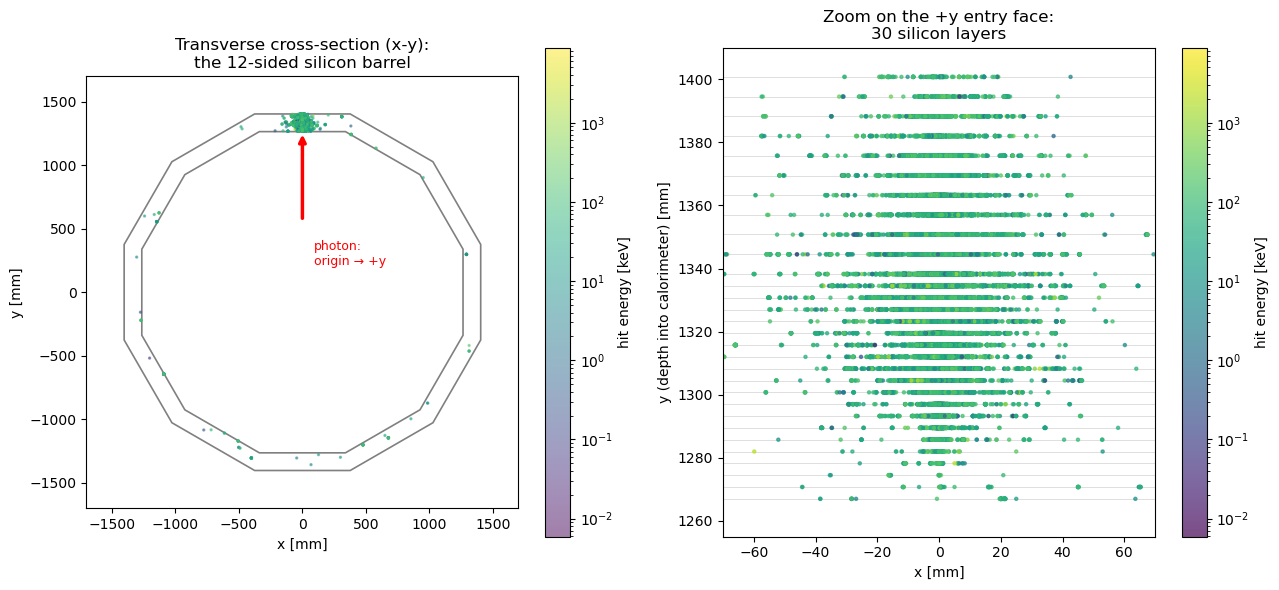

Left: the whole shower in the barrel cross-section — most hits on the +y face, the rest is leakage across the cavity.
Right: zoomed to the entry face; the 30 horizontal lines are the silicon sensor layers the shower crosses.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.patches import RegularPolygon

x_np = ak.to_numpy(x); y_np = ak.to_numpy(y); z_np = ak.to_numpy(z)
e_keV = ak.to_numpy(e) * 1e6   # GeV -> keV for the colour scale

# Barrel geometry (from geometry/SiD_TestBeam.xml): 12-sided, r = 1264..1403 mm,
# axis along z. The ring therefore lives in the x-y plane.
NSIDES, RMIN, RMAX = 12, 1264.0, 1403.0

def dodecagon(apothem):
    # RegularPolygon wants the circumradius (centre->vertex) = apothem / cos(pi/n);
    # rotate by pi/n so a flat FACE (not a vertex) points +y, matching the entry face.
    return RegularPolygon((0, 0), numVertices=NSIDES,
                          radius=apothem / np.cos(np.pi / NSIDES),
                          orientation=np.pi / NSIDES,
                          fill=False, edgecolor="0.5", lw=1.2)

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# Panel 1 — full transverse ring (x-y), all hits + the 12-sided silicon shell
ax = axes[0]
ax.add_patch(dodecagon(RMIN)); ax.add_patch(dodecagon(RMAX))
sc = ax.scatter(x_np, y_np, c=e_keV, cmap="viridis", s=2, alpha=0.5, norm=LogNorm())
# photon starts at the ORIGIN and travels +y outward, entering the INNER face
ax.annotate("", xy=(0, RMIN), xytext=(0, 560),
            arrowprops=dict(arrowstyle="-|>", color="red", lw=2.5))
ax.text(90, 300, "photon:\norigin → +y", color="red", fontsize=9, va="center")
ax.set_aspect("equal"); ax.set_xlim(-1700, 1700); ax.set_ylim(-1700, 1700)
ax.set_xlabel("x [mm]"); ax.set_ylabel("y [mm]")
ax.set_title("Transverse cross-section (x-y):\nthe 12-sided silicon barrel")
fig.colorbar(sc, ax=ax, label="hit energy [keV]")

# Panel 2 — zoom on the +y entry face, with the silicon layers as lines
ax = axes[1]
face = (y_np > 1240) & (np.abs(x_np) < 70)
layer_y = np.unique(np.round(y_np[face], 1))
for ly in layer_y:
    ax.axhline(ly, color="0.85", lw=0.6, zorder=0)
sc2 = ax.scatter(x_np[face], y_np[face], c=e_keV[face], cmap="viridis", s=5,
                 alpha=0.7, norm=LogNorm())
ax.set_xlim(-70, 70); ax.set_ylim(1255, 1410)
ax.set_xlabel("x [mm]"); ax.set_ylabel("y (depth into calorimeter) [mm]")
ax.set_title(f"Zoom on the +y entry face:\n{len(layer_y)} silicon layers")
fig.colorbar(sc2, ax=ax, label="hit energy [keV]")

plt.tight_layout()
plt.show()
print(f"Left: the whole shower in the barrel cross-section — most hits on the +y face, "
      f"the rest is leakage across the cavity.")
print(f"Right: zoomed to the entry face; the {len(layer_y)} horizontal lines are the "
      f"silicon sensor layers the shower crosses.")

## 6. How the shower develops through the detector

Now follow this one shower *into* the calorimeter. We keep the +y entry segment,
assign every hit to its silicon layer (by radius), and look at three views:

1. **One layer at 100 µm resolution** — zoom into the densest layer so the
   individual pixels are visible. This *is* the quantization: each lit square is
   a 100 µm × 100 µm yes/no pixel.
2. **Layer-by-layer evolution** — the transverse hit pattern in all 30 layers,
   showing the shower start narrow, fan out at shower-max, then fade.
3. **Longitudinal profile** — total energy per layer vs depth for this single
   event (compare to the energy-averaged version in `02_data_extraction`).

In [7]:
import numpy as np
e_np = ak.to_numpy(e)                       # this event's hit energies (GeV)
RADII = np.array(sensor_y_planes)           # 30 silicon layer radii from the XML

# the +y entry face is a flat facet -> Si layers sit at CONSTANT y; index the
# layer by depth y (not the z-axis radius hypot(x,y)).
ang  = np.degrees(np.arctan2(x_np, y_np))
seg  = (np.abs(ang) < 15) & (y_np > 1260) & (y_np < 1410)
xs, zs, es, ys = x_np[seg], z_np[seg], e_np[seg], y_np[seg]
lyr = np.argmin(np.abs(RADII[None, :] - ys[:, None]), axis=1)
print(f"{seg.sum()} hits in the +y segment, spread over {len(np.unique(lyr))} layers")

45181 hits in the +y segment, spread over 30 layers


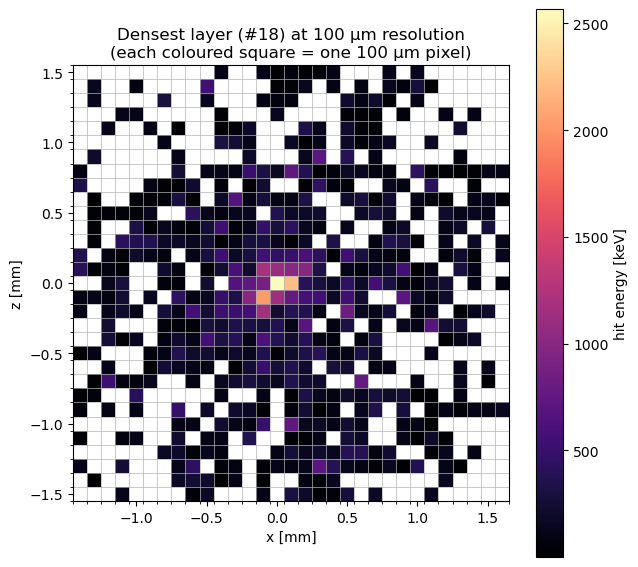

In [8]:
# 1. One layer at 100 um resolution -- the pixelization, made visible.
# Render real pixel CELLS (pcolormesh on the integer pixel grid) so each lit
# pixel is exactly one 100 um grid square, neatly aligned to the gridlines.
PITCH = 0.1
dense = np.bincount(lyr, minlength=len(RADII)).argmax()
m = lyr == dense
xi = np.round(xs[m] / PITCH).astype(int)
zi = np.round(zs[m] / PITCH).astype(int)
ei = es[m] * 1e6                                   # keV
ci_x, ci_z, half = int(np.median(xi)), int(np.median(zi)), 15   # +-15 px = +-1.5 mm
nx = nz = 2 * half + 1
img = np.full((nz, nx), np.nan)
for ix, iz, ee in zip(xi, zi, ei):
    jx, jz = ix - (ci_x - half), iz - (ci_z - half)
    if 0 <= jx < nx and 0 <= jz < nz:
        img[jz, jx] = ee if np.isnan(img[jz, jx]) else img[jz, jx] + ee
# cell EDGES in mm -> every coloured square spans exactly one 100 um pixel
xed = (np.arange(ci_x - half, ci_x + half + 2) - 0.5) * PITCH
zed = (np.arange(ci_z - half, ci_z + half + 2) - 0.5) * PITCH

fig, ax = plt.subplots(figsize=(6.5, 6))
pcm = ax.pcolormesh(xed, zed, img, cmap="magma")
ax.set_xticks(xed, minor=True); ax.set_yticks(zed, minor=True)
ax.grid(which="minor", color="0.7", lw=0.5)
ax.set_aspect("equal")
ax.set_xlabel("x [mm]"); ax.set_ylabel("z [mm]")
ax.set_title(f"Densest layer (#{dense}) at 100 µm resolution\n(each coloured square = one 100 µm pixel)")
fig.colorbar(pcm, ax=ax, label="hit energy [keV]")
plt.tight_layout(); plt.show()

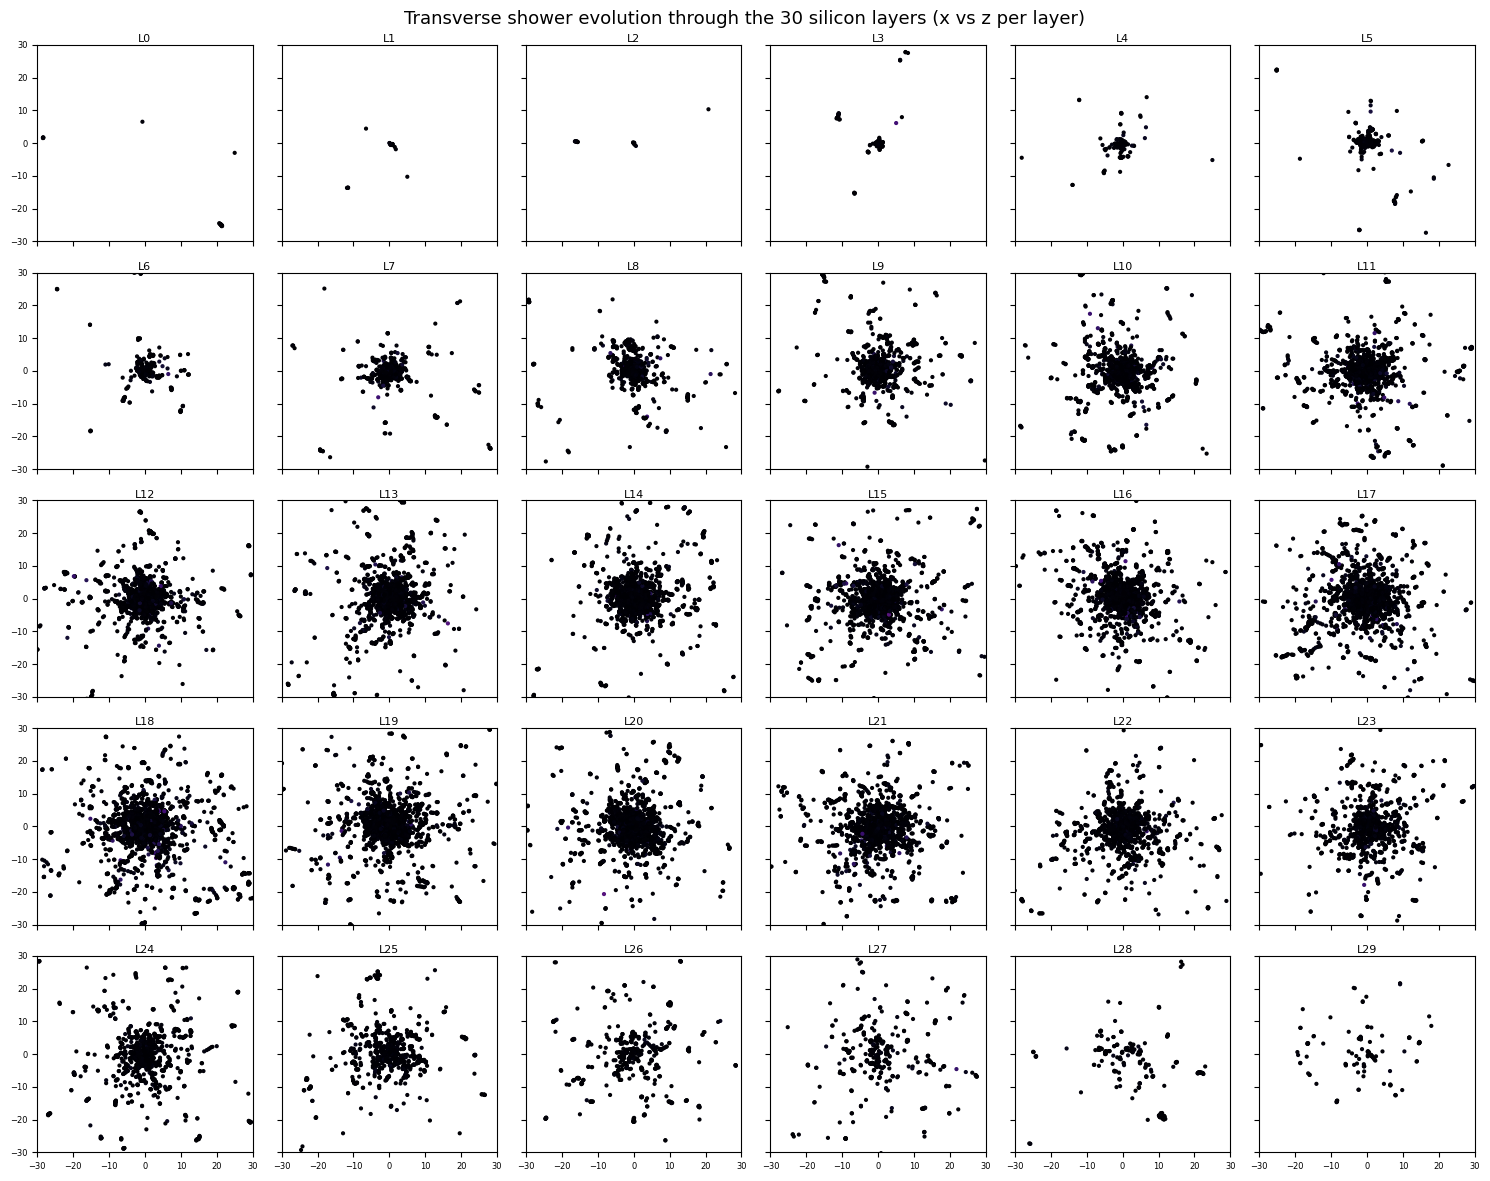

In [9]:
# 2. Transverse shower evolution, layer by layer
nlayers = len(RADII)
fig, axes = plt.subplots(5, 6, figsize=(15, 12), sharex=True, sharey=True)
vmax = (es * 1e6).max() if len(es) else 1.0
for i, ax in enumerate(axes.flat):
    if i >= nlayers:
        ax.axis("off"); continue
    m = lyr == i
    if m.any():
        ax.scatter(xs[m], zs[m], c=es[m] * 1e6, cmap="magma", s=4, vmin=0, vmax=vmax)
    ax.set_xlim(-30, 30); ax.set_ylim(-30, 30)
    ax.set_title(f"L{i}", fontsize=8, pad=2)
    ax.tick_params(labelsize=6)
fig.suptitle("Transverse shower evolution through the 30 silicon layers (x vs z per layer)", fontsize=13)
plt.tight_layout(); plt.show()

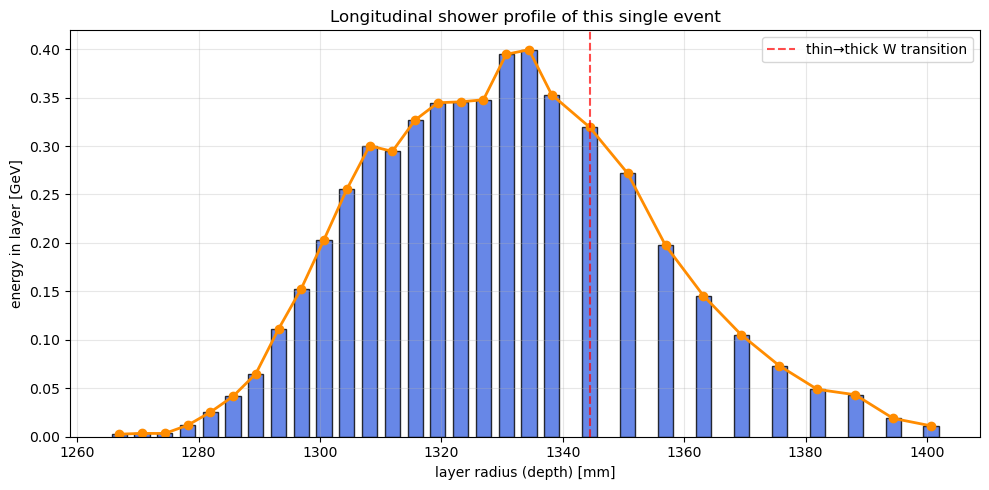

In [10]:
# 3. Longitudinal profile of this single event
le = np.bincount(lyr, weights=es, minlength=nlayers)[:nlayers]
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(RADII, le, width=2.5, color="royalblue", edgecolor="black", alpha=0.8)
ax.plot(RADII, le, color="darkorange", marker="o", lw=2)
if nlayers > 20:
    ax.axvline(RADII[20], color="red", ls="--", alpha=0.7, label="thin→thick W transition")
    ax.legend()
ax.set_xlabel("layer radius (depth) [mm]"); ax.set_ylabel("energy in layer [GeV]")
ax.set_title("Longitudinal shower profile of this single event")
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 6b. The shower, quantified: shower max, ln E scaling, transverse containment

One event is anecdote; now measure the *average* shower and check it against the
textbook. Electromagnetic cascades obey a remarkably universal description when depth
is measured in radiation lengths $t = x/X_0$ (§3b): the average longitudinal profile
follows the Longo–Sestili $\Gamma$-shape

$$\frac{dE}{dt} \propto t^{\,a-1} e^{-bt},\qquad t_{\rm max} = \frac{a-1}{b} \approx \ln\frac{E}{E_c} + C_\gamma,$$

with $C_\gamma \approx +0.5$ for photon-induced showers and $E_c \approx 8$ MeV for
tungsten. Two things to verify with our own data:

1. **The profile shape and the depth of shower max** — fit the $\Gamma$-form to the
   average profile in a few energy slices; $t_{\rm max}$ should grow only
   *logarithmically* with energy and approach $\ln(E/E_c) + 0.5$ (from below — see
   "how to read" below). That logarithm is the entire reason a 400 GeV photon fits in the
   same ~26 $X_0$ as a 5 GeV one.
2. **Transverse containment** — perpendicular to the shower axis the spread is set by
   multiple scattering, characterized by the **Molière radius**
   $R_M \approx X_0 \cdot (21.2\ {\rm MeV})/E_c \approx 1$ cm here; the textbook
   statement is that ~90% of the shower energy sits within 1 $R_M$ of the axis. Ours
   is a *sampling* stack (low-density gaps between the tungsten plates), so we
   *measure* the containment radii rather than assume the bulk value.

**How to read the results.** The physics claim is that shower max grows only
*logarithmically*: the fitted $t_{\rm max}$ climbs from ~6.6 $X_0$ at 10 GeV to ~10.8 $X_0$
at ~316 GeV — a 32× jump in energy moves the peak by only ~4 $X_0$, not 32× — so a 400 GeV
shower and a 10 GeV shower both fit inside the same ~26 $X_0$. That is the point of the plot,
and it holds cleanly. The *absolute* $t_{\rm max}$ sits **below** the $\ln(E/E_c) + 0.5$ rule
of thumb, and the gap **shrinks with energy** — about 1 $X_0$ at 10 GeV, ~0.3 $X_0$ by
316 GeV, converging onto the line where the statistics and sampling are best. Two honest
caveats explain the low-energy deficit rather than a detector problem: the $+0.5$ additive
constant is itself only an approximation (Rossi's Approximation B), and the lowest slice here
has only ~24 events, so its $\Gamma$ fit (the noisiest point) is the least reliable — which is
exactly where the deficit is largest. The estimator matters, too: because every layer carries
the **same** 320 µm silicon, the per-layer Si energy is directly proportional to $dE/dt$ (the
sampling fraction times the cell's radiation-length span is constant across the thin→thick
transition), so we plot it **without** any per-cell normalization — dividing by each cell's
$X_0$ span instead would impose a spurious ×2 step at layer 21 and bias the high-energy peak.

For the containment, the bulk-alloy $R_M \approx 10$ mm is a *lower bound*: roughly a quarter
of the stack's thickness (37.5 of 137.5 mm) is low-density gap material (air / Si / Cu /
Kapton), so per millimetre of *stack* the effective radiation length is diluted by about ×1.4,
predicting an effective $R_M \approx 14$ mm — and the measured 90%-containment radius
(16.5 mm) lands just above it, as expected for a sampling stack.

The next cell reads a few hundred events in parallel (a minute or two); the two after
it make the plots.


In [11]:
# Average longitudinal profiles + a radial energy profile, from NREAD files in parallel.
from concurrent.futures import ProcessPoolExecutor

NREAD  = 150
SLICES = [(8, 12), (25, 40), (80, 120), (250, 400)]     # GeV slices for the profile fits
RBINS  = np.linspace(0, 150, 151)                       # transverse-distance bins [mm]
RADII_ARR = np.array(sensor_y_planes)

def _profile_worker(fp):
    import uproot as _up, numpy as _np
    prof = {k: [_np.zeros(len(RADII_ARR)), 0] for k in range(len(SLICES))}
    radial = _np.zeros(len(RBINS) - 1); rad_n = 0
    try:
        with _up.open(fp) as f:
            a = f["events"].arrays(["ECalBarrelHits.position.x", "ECalBarrelHits.position.y",
                                    "ECalBarrelHits.position.z", "ECalBarrelHits.energy",
                                    "MCParticles.momentum.y"])
        for ev in range(len(a["MCParticles.momentum.y"])):
            Et = float(a["MCParticles.momentum.y"][ev][0])
            x = _np.asarray(a["ECalBarrelHits.position.x"][ev]); y = _np.asarray(a["ECalBarrelHits.position.y"][ev])
            z = _np.asarray(a["ECalBarrelHits.position.z"][ev]); e = _np.asarray(a["ECalBarrelHits.energy"][ev])
            m = (_np.abs(_np.degrees(_np.arctan2(x, y))) < 15) & (y > 1260) & (y < 1410)
            if not m.any():
                continue
            x, y, z, e = x[m], y[m], z[m], e[m]
            lyr = _np.argmin(_np.abs(RADII_ARR[None, :] - y[:, None]), axis=1)
            le = _np.bincount(lyr, weights=e, minlength=len(RADII_ARR))
            for k, (lo, hi) in enumerate(SLICES):
                if lo <= Et < hi:
                    prof[k][0] += le; prof[k][1] += 1
                    break
            if SLICES[1][0] <= Et < SLICES[1][1]:       # containment measured in the second slice
                ax0 = _np.average(x, weights=e); az0 = _np.average(z, weights=e)
                radial += _np.histogram(_np.hypot(x - ax0, z - az0), bins=RBINS, weights=e)[0]
                rad_n += 1
    except Exception:
        return None
    return prof, radial, rad_n

files_many = sorted(glob.glob(os.path.join(DATA_BASE, "data_spectrum_100um_400GeV",
                                           "sim_photons_part*.root")))[:NREAD]
prof = {k: [np.zeros(len(RADII_ARR)), 0] for k in range(len(SLICES))}
radial = np.zeros(len(RBINS) - 1); rad_n = 0
with ProcessPoolExecutor(max_workers=min(32, os.cpu_count() or 8)) as ex:
    for r in ex.map(_profile_worker, files_many):
        if r is None:
            continue
        o, rr, rn = r
        for k in o:
            prof[k][0] += o[k][0]; prof[k][1] += o[k][1]
        radial += rr; rad_n += rn
print("events per slice:", {f"{lo}-{hi} GeV": prof[k][1] for k, (lo, hi) in enumerate(SLICES)},
      f"| containment events: {rad_n}")


events per slice: {'8-12 GeV': 24, '25-40 GeV': 130, '80-120 GeV': 310, '250-400 GeV': 1169} | containment events: 130


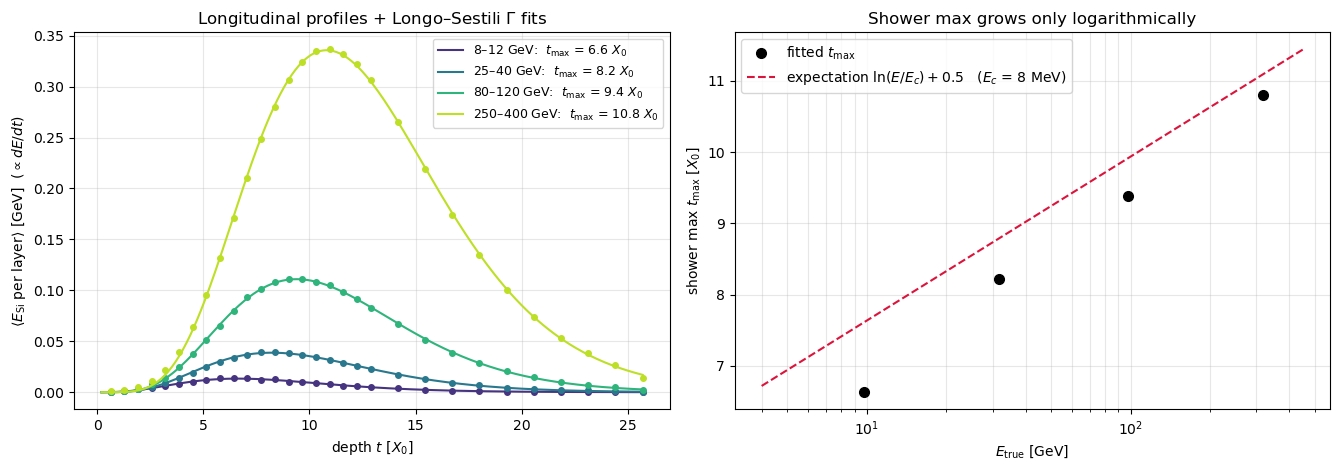

  E ~    10 GeV: fitted t_max =   6.6 X0   expected   7.6 X0
  E ~    32 GeV: fitted t_max =   8.2 X0   expected   8.8 X0
  E ~    98 GeV: fitted t_max =   9.4 X0   expected   9.9 X0
  E ~   316 GeV: fitted t_max =  10.8 X0   expected  11.1 X0


In [12]:
# Gamma fits to the average profiles, and shower max vs ln(E)
from scipy.optimize import curve_fit

def gamma_prof(t, A, a, b):
    return A * t**(a - 1) * np.exp(-b * t)

fig, ax = plt.subplots(1, 2, figsize=(13.5, 4.8))
cmapv = plt.cm.viridis(np.linspace(0.15, 0.9, len(SLICES)))
tmax_pts = []
for k, (lo, hi) in enumerate(SLICES):
    if prof[k][1] == 0:
        continue
    y = prof[k][0] / prof[k][1]               # per-event Si energy per layer. Every layer has the
                                          # SAME 320 um Si, and the sampling fraction f_i times
                                          # the cell X0-span is constant (thick cells: half f_i,
                                          # double span), so E_Si per layer is directly
                                          # proportional to dE/dt -- no per-cell normalization.
    ax[0].plot(t_si, y, "o", ms=4, color=cmapv[k])
    p, _ = curve_fit(gamma_prof, t_si, y, p0=[y.max(), 5.0, 0.5], maxfev=20000)
    tt = np.linspace(0.2, t_si.max(), 300)
    tmax = (p[1] - 1) / p[2]
    ax[0].plot(tt, gamma_prof(tt, *p), "-", color=cmapv[k],
               label=rf"{lo}–{hi} GeV:  $t_{{\rm max}}$ = {tmax:.1f} $X_0$")
    tmax_pts.append((np.sqrt(lo * hi), tmax))
ax[0].set_xlabel("depth $t$ [$X_0$]"); ax[0].set_ylabel(r"$\langle E_{\rm Si}$ per layer$\rangle$ [GeV]  ($\propto dE/dt$)")
ax[0].set_title(r"Longitudinal profiles + Longo–Sestili $\Gamma$ fits")
ax[0].legend(fontsize=9); ax[0].grid(alpha=0.3)

Es = np.array([q[0] for q in tmax_pts]); tm = np.array([q[1] for q in tmax_pts])
ax[1].semilogx(Es, tm, "o", ms=7, color="k", label=r"fitted $t_{\rm max}$")
Ex = np.logspace(np.log10(4), np.log10(450), 100)
ax[1].semilogx(Ex, np.log(Ex * 1000 / E_C_MEV) + 0.5, "--", color="crimson",
               label=r"expectation $\ln(E/E_c) + 0.5$   ($E_c$ = 8 MeV)")
ax[1].set_xlabel(r"$E_{\rm true}$ [GeV]"); ax[1].set_ylabel(r"shower max $t_{\rm max}$ [$X_0$]")
ax[1].set_title("Shower max grows only logarithmically")
ax[1].legend(); ax[1].grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for (E0, t0) in tmax_pts:
    print(f"  E ~ {E0:5.0f} GeV: fitted t_max = {t0:5.1f} X0   expected {np.log(E0*1000/E_C_MEV)+0.5:5.1f} X0")


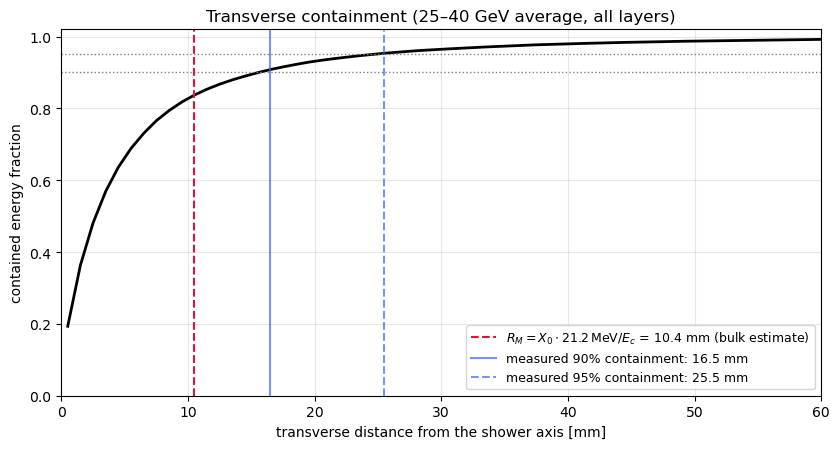

bulk-alloy Moliere estimate R_M = 10.4 mm; measured R90 = 16.5 mm (above it), R95 = 25.5 mm
The stack is a SAMPLING structure (low-density gaps between the W plates), so the measured
containment need not equal the bulk estimate exactly -- same order is the expectation.


In [13]:
# Transverse containment vs the Moliere radius
rc = 0.5 * (RBINS[1:] + RBINS[:-1])
cumfrac = np.cumsum(radial) / radial.sum()
R_M = X0_alloy * 21.2 / E_C_MEV
r90 = rc[np.searchsorted(cumfrac, 0.90)]; r95 = rc[np.searchsorted(cumfrac, 0.95)]
fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.plot(rc, cumfrac, color="k", lw=2)
ax.axhline(0.90, color="gray", ls=":", lw=1); ax.axhline(0.95, color="gray", ls=":", lw=1)
ax.axvline(R_M, color="crimson", ls="--",
           label=f"$R_M = X_0 \\cdot 21.2\\,$MeV$/E_c$ = {R_M:.1f} mm (bulk estimate)")
ax.axvline(r90, color="royalblue", ls="-", alpha=0.7, label=f"measured 90% containment: {r90:.1f} mm")
ax.axvline(r95, color="royalblue", ls="--", alpha=0.7, label=f"measured 95% containment: {r95:.1f} mm")
ax.set_xlabel("transverse distance from the shower axis [mm]")
ax.set_ylabel("contained energy fraction")
ax.set_title(f"Transverse containment ({SLICES[1][0]}–{SLICES[1][1]} GeV average, all layers)")
ax.legend(fontsize=9); ax.grid(alpha=0.3); ax.set_xlim(0, 60); ax.set_ylim(0, 1.02)
plt.tight_layout(); plt.show()
rel = "above" if r90 > R_M else "below"
print(f"bulk-alloy Moliere estimate R_M = {R_M:.1f} mm; measured R90 = {r90:.1f} mm ({rel} it), R95 = {r95:.1f} mm")
print("The stack is a SAMPLING structure (low-density gaps between the W plates), so the measured")
print("containment need not equal the bulk estimate exactly -- same order is the expectation.")


## 7. Reverse-engineer the geometry from the data

A nice sanity check: we should be able to *recover* the pixel pitch and the layer
count straight from the hit positions and confirm they match the XML — proving
the simulation quantizes the way we expect.

In [14]:
files = sorted(glob.glob(os.path.join(DATA_BASE, "data_spectrum_100um_400GeV", "sim_photons_part*.root")))
filepath = files[0]
print(f"opening {filepath}")

with uproot.open(filepath) as f:
    tree = f["events"]
    x_j = tree["ECalBarrelHits/ECalBarrelHits.position.x"].array()
    y_j = tree["ECalBarrelHits/ECalBarrelHits.position.y"].array()
    z_j = tree["ECalBarrelHits/ECalBarrelHits.position.z"].array()

x_all = ak.flatten(x_j).to_numpy()
y_all = ak.flatten(y_j).to_numpy()
z_all = ak.flatten(z_j).to_numpy()

# Filter to the +Y face only (where the photons enter)
mask = (np.abs(x_all) <= 50) & (np.abs(z_all) <= 50) & (y_all >= 1260) & (y_all <= 1410)
x, y, z = x_all[mask], y_all[mask], z_all[mask]
print(f"Total hits in file:        {len(x_all)}")
print(f"Hits in +Y target volume:  {len(x)}")


opening /home/murtazas/CALOMAPS-data/data_spectrum_100um_400GeV/sim_photons_part1.root


Total hits in file:        464945
Hits in +Y target volume:  456118


In [15]:
unique_x = np.unique(np.round(x, 4))
unique_y = np.unique(np.round(y, 4))
unique_z = np.unique(np.round(z, 4))

dx = np.diff(unique_x)
dz = np.diff(unique_z)
pitch_x = np.min(dx[dx > 0]) if len(dx) > 0 else 0
pitch_z = np.min(dz[dz > 0]) if len(dz) > 0 else 0

print(f"Pixel X pitch (from data):  {pitch_x:.5f} mm    (expect 0.1 mm = 100 um)")
print(f"Pixel Z pitch (from data):  {pitch_z:.5f} mm")
print(f"Sensor layers (from data):  {len(unique_y)}      (expect 30 from XML)")
_rad = np.array(sensor_y_planes)
_off = float(np.max(np.abs(_rad - unique_y[:len(_rad)])))
_halfpitch = float(np.median(np.diff(_rad)) / 2.0)
print(f"XML-vs-data layer-y max offset: {_off:.3f} mm  "
      f"({'within' if _off < _halfpitch else 'EXCEEDS'} the {_halfpitch:.2f} mm half-pitch "
      f"-> layer indexing {'unaffected' if _off < _halfpitch else 'BIASED'})")


Pixel X pitch (from data):  0.10000 mm    (expect 0.1 mm = 100 um)
Pixel Z pitch (from data):  0.10000 mm
Sensor layers (from data):  30      (expect 30 from XML)
XML-vs-data layer-y max offset: 0.100 mm  (within the 1.88 mm half-pitch -> layer indexing unaffected)


## 8. First-look aggregates

Finally, look across all events in this one file: how the digital (hit count) and
analog (visible energy) readouts grow with true energy, and what the **sampling
fraction** (visible/true) actually is for this design — *measured* from the data,
not assumed.

> **Scope of this sampling fraction:** this first look sums **all** hits in the event (the whole 12-sided ring). Notebook 02 keeps only the **+y wedge**, so its visible-energy readout -- and the sampling fraction the resolution notebooks (03/04) work with -- is a smaller, wedge-restricted subset. The two are not directly comparable.

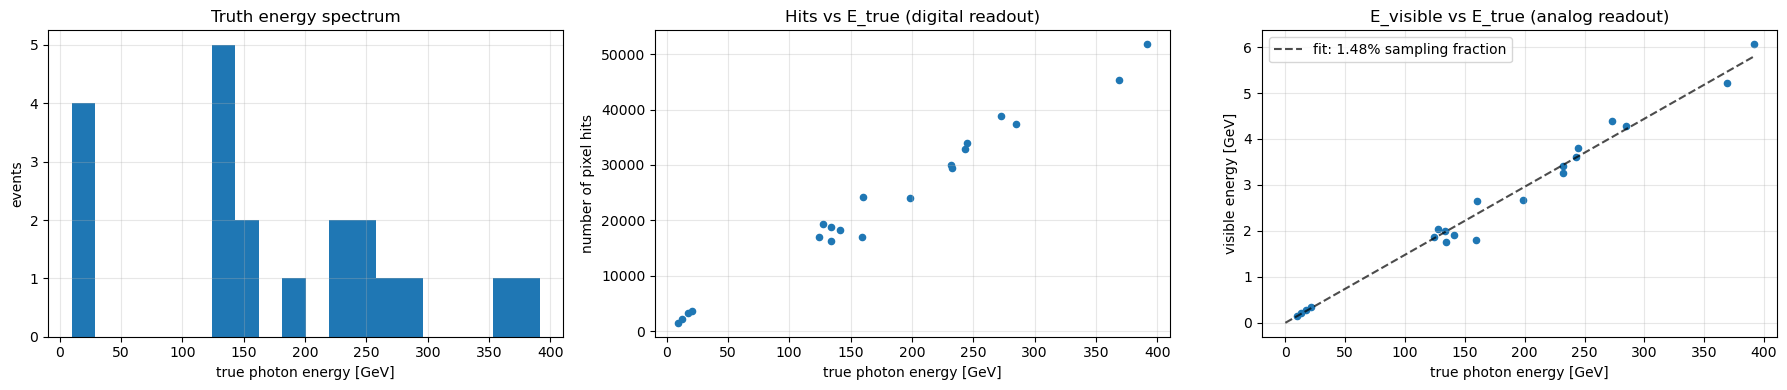

In [16]:
with uproot.open(filepath) as f:
    tree = f["events"]
    x_all = tree["ECalBarrelHits/ECalBarrelHits.position.x"].array()
    e_all = tree["ECalBarrelHits/ECalBarrelHits.energy"].array()
    p_all = tree["MCParticles/MCParticles.momentum.y"].array()

hits_per_event = ak.num(x_all)
total_e_per_event = ak.sum(e_all, axis=1)
true_e_per_event = ak.flatten(p_all)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(true_e_per_event, bins=20)
axes[0].set_xlabel("true photon energy [GeV]")
axes[0].set_ylabel("events")
axes[0].set_title("Truth energy spectrum")
axes[0].grid(True, alpha=0.3)

axes[1].scatter(true_e_per_event, hits_per_event, s=20)
axes[1].set_xlabel("true photon energy [GeV]")
axes[1].set_ylabel("number of pixel hits")
axes[1].set_title("Hits vs E_true (digital readout)")
axes[1].grid(True, alpha=0.3)

axes[2].scatter(true_e_per_event, total_e_per_event, s=20)
# The sampling fraction is design-dependent (Si/W thickness ratio, layer count, ...),
# so we MEASURE it from the data instead of assuming a fixed value. Fit through the
# origin: E_visible = f * E_true. Change the geometry and this number changes.
_t = np.asarray(true_e_per_event, dtype=float)
_v = np.asarray(total_e_per_event, dtype=float)
samp_frac = float(np.sum(_t * _v) / np.sum(_t * _t))
_xline = np.array([0.0, _t.max()])
axes[2].plot(_xline, samp_frac * _xline, "k--", alpha=0.7,
             label=f"fit: {samp_frac*100:.2f}% sampling fraction")
axes[2].set_xlabel("true photon energy [GeV]")
axes[2].set_ylabel("visible energy [GeV]")
axes[2].set_title("E_visible vs E_true (analog readout)")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. The MIP — the readout's energy quantum

The digital readout doesn't measure energy; it counts pixels above a threshold. The
natural scale for that threshold is the **MIP** — the energy a minimum-ionizing particle
deposits crossing the full 320 µm silicon sensor: a Landau distribution whose
most-probable value (MPV) is ≈ 24,000 electron–hole pairs × 3.7 eV ≈ **85–90 keV**. That
number is measured directly in this pipeline: notebook
[06 §8b](06_sensor_crossings_tracker.ipynb) selects near-perpendicular, full-thickness
sensor crossings from the tracker readout and finds a Landau MPV of ~85–90 keV — exactly
the `MIP_ENERGY = 85 keV` the extraction
([`02_data_extraction.ipynb`](02_data_extraction.ipynb)) is normalized to.

The histogram below is a related but different object: the **per-pixel** deposit
spectrum. Its peak sits near **30 keV — a third of a MIP — and that is geometry, not a
contradiction**: a shower particle crossing the sensor at a typical (inclined) angle
spreads its track over several 100 µm pixels, so one pixel sees only a ~100 µm segment of
path, and 85 keV × (100 µm / 320 µm) ≈ 27 keV. Three populations to recognize:

- the **partial-path peak** near 30 keV — pixel-length track segments, the bulk of the
  hits (the shower sea is soft and wide-angled);
- a **full-crossing shoulder** around 85 keV (dashed line) — near-perpendicular tracks
  that deposit their whole crossing in one pixel;
- a **multi-particle tail** above that — in the dense shower core several particles cross
  the *same* pixel in one event and stack their deposits. That stacking is exactly the
  saturation mechanism that makes the binary readout bend over at high energy
  (notebooks 02/03).

The **½-MIP threshold** (dotted) is the zero-suppression cut a real binary chip would
apply, defined against the *full-crossing* MIP. On the per-pixel spectrum it sits *above*
the partial-path peak, so it removes a sizeable fraction of the soft segment hits (the
printout quantifies it) while keeping every full crossing — a genuine design trade-off of
per-pixel thresholding at this pitch, worth keeping in mind when interpreting the digital
readouts.


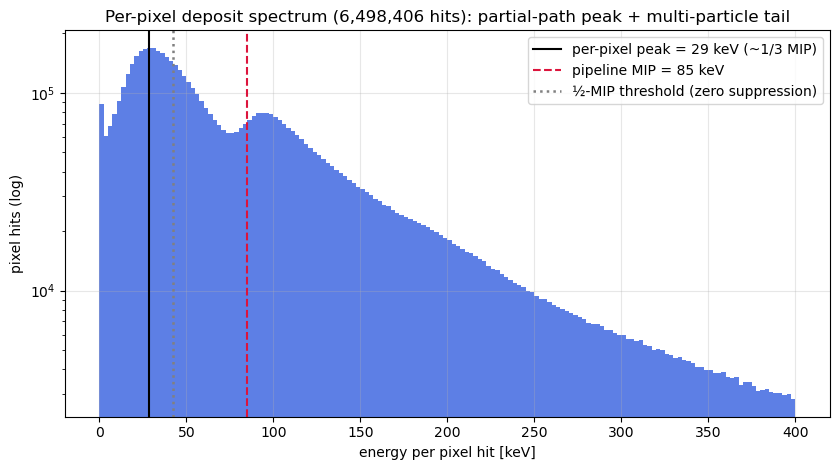

per-pixel spectrum peak = 29 keV (~1/3 of a MIP: partial track path per pixel; the full-crossing MIP is measured in notebook 06 section 8b)
hits below the ½-MIP threshold (zero-suppressed by nb02): 33.8%


In [17]:
# per-pixel deposit spectrum over a few files -> the silicon MIP scale
NF = 12
evals = []
for fp in files_many[:NF]:
    with uproot.open(fp) as f:
        evals.append(ak.flatten(f["events"]["ECalBarrelHits/ECalBarrelHits.energy"].array()).to_numpy())
e_keV_all = np.concatenate(evals) * 1e6
MIP_KEV = 85.0
bins = np.linspace(0, 400, 161)
h, edges = np.histogram(e_keV_all, bins=bins)
mpv = 0.5 * (edges[np.argmax(h)] + edges[np.argmax(h) + 1])
fig, ax = plt.subplots(figsize=(8.5, 4.8))
ax.hist(e_keV_all, bins=bins, color="royalblue", alpha=0.85)
ax.axvline(mpv, color="k", lw=1.5, label=f"per-pixel peak = {mpv:.0f} keV (~1/3 MIP)")
ax.axvline(MIP_KEV, color="crimson", ls="--", lw=1.5, label=f"pipeline MIP = {MIP_KEV:.0f} keV")
ax.axvline(MIP_KEV / 2, color="gray", ls=":", lw=1.8, label="½-MIP threshold (zero suppression)")
ax.set_yscale("log")
ax.set_xlabel("energy per pixel hit [keV]"); ax.set_ylabel("pixel hits (log)")
ax.set_title(f"Per-pixel deposit spectrum ({len(e_keV_all):,} hits): partial-path peak + multi-particle tail")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f"per-pixel spectrum peak = {mpv:.0f} keV (~1/3 of a MIP: partial track path per pixel; "
      f"the full-crossing MIP is measured in notebook 06 section 8b)")
print(f"hits below the ½-MIP threshold (zero-suppressed by nb02): {(e_keV_all < MIP_KEV / 2).mean():.1%}")


## The detector in one paragraph

The DECAL is a **quantized sampling calorimeter**: a 12-sided silicon barrel,
30 layers deep, every layer tiled into 100 µm yes/no pixels. From the geometry and
the data themselves we measured the numbers that define it: **~25.7 X₀ / ~1 λ_I**
deep (§3b — an EM calorimeter by construction), shower max near
**ln(E/E_c) + 0.5** growing only logarithmically (§6b), transverse containment of
order the **Molière radius ~1 cm** (§6b), a **sampling fraction of ~1.4%** (§8),
and the **85 keV full-crossing MIP scale** behind the ½-MIP readout threshold
(§9 — measured per-crossing in notebook 06 §8b, with the per-pixel spectrum explained
by path-length geometry).
Two physics threads run through the rest of the project:

- **Sampling**: only ~1.4% of the photon's energy lands in the silicon (the rest
  is absorbed in the tungsten) — the *sampling fraction*, set by the Si/W
  geometry, and the source of the **stochastic** resolution term.
- **Quantization**: counting lit pixels (digital) tracks energy at low E, but at
  high E the shower core puts many particles through one pixel, which can only
  fire once — **saturation** (visible as the multi-particle tail in §9). Whether
  the digital readout's resolution beats or loses to analog, and where the
  crossover sits, is exactly what
  [`02_data_extraction.ipynb`](02_data_extraction.ipynb),
  [`03_resolution_conventional.ipynb`](03_resolution_conventional.ipynb) and
  [`04_resolution_ml_crystalball.ipynb`](04_resolution_ml_crystalball.ipynb)
  quantify.
